## 1. Descargar librerias


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [3]:
def cargar_datos(path):
    path_file = 'datos/campanas_influencer_ugc.csv'
    path_complete = os.path.join(os.getcwd(), path_file)
    df = pd.read_csv(path_complete, parse_dates=['fecha'])
    return df

In [4]:
path = 'datos/campanas_influencer_ugc.csv'
df = cargar_datos(path)

In [5]:
df.head()

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score
0,UGC-0001,2025-02-02,BeatKitchen,Food,MX,ValeTrend,mid,Instagram,Review,276060,2651.57,25.08,246.96,2923.61,126189,103134,7091,985,1134,1778,6020,962,17709.02,0.691
1,UGC-0002,2025-02-03,NovaSkin,Fitness,CL,JotaMedia,mid,YouTube Shorts,Tutorial,145653,2432.51,176.29,391.03,2999.84,23014,17991,2043,381,291,332,203,7,333.97,0.831
2,UGC-0003,2025-02-04,CasaZen,Home,CL,AnaCrea,micro,Instagram,Review,51534,1070.11,38.64,20.09,1128.84,17337,14564,667,125,88,96,146,10,874.15,0.768
3,UGC-0004,2025-02-05,NovaSkin,Fitness,AR,MaraCreator,macro,TikTok,Tutorial,1558499,11905.76,50.99,230.21,12186.96,621828,481091,24561,5027,3224,7160,19214,915,42697.58,0.771
4,UGC-0005,2025-02-06,NovaSkin,Fitness,PE,NicoFlow,micro,Instagram,Review,90504,1176.24,180.68,278.89,1635.81,29190,25365,1359,240,273,354,327,38,1588.59,0.745


In [6]:
#Tamano del DataFrame
#print(f"El dataframe contiene: {len(df)},\nel número de filas es: {len(df.columns)}")
print(f"Filas:{df.shape[0]}, Columnas:{df.shape[1]}")
print(f"Tipo de datos:\n{df.dtypes}")

Filas:200, Columnas:24
Tipo de datos:
id_campana                      object
fecha                   datetime64[ns]
marca                           object
vertical                        object
pais                            object
influencer                      object
tier                            object
plataforma                      object
tipo_contenido                  object
seguidores                       int64
fee_influencer_usd             float64
costo_produccion_usd           float64
paid_boost_usd                 float64
costo_total_usd                float64
views                            int64
reach                            int64
likes                            int64
comments                         int64
shares                           int64
saves                            int64
link_clicks                      int64
conversiones                     int64
ingresos_usd                   float64
sentimiento_score              float64
dtype: object


In [7]:
df.isna()

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isna().sum()

id_campana              0
fecha                   0
marca                   0
vertical                0
pais                    0
influencer              0
tier                    0
plataforma              0
tipo_contenido          0
seguidores              0
fee_influencer_usd      0
costo_produccion_usd    0
paid_boost_usd          0
costo_total_usd         0
views                   0
reach                   0
likes                   0
comments                0
shares                  0
saves                   0
link_clicks             0
conversiones            0
ingresos_usd            0
sentimiento_score       0
dtype: int64

In [9]:
print(f"Categorias de tipo de influener: {df.tier.unique()},\nPlataforma: {df.plataforma.unique()},\nTipo de contenido: {df.tipo_contenido.unique()}")

Categorias de tipo de influener: ['mid' 'micro' 'macro' 'nano'],
Plataforma: ['Instagram' 'YouTube Shorts' 'TikTok'],
Tipo de contenido: ['Review' 'Tutorial' 'UGC_Paid' 'Challenge' 'UGC_Organic']


In [11]:
df.tier.value_counts().index

Index(['micro', 'nano', 'mid', 'macro'], dtype='object', name='tier')

In [9]:
df.pais.unique()

array(['MX', 'CL', 'AR', 'PE', 'CO'], dtype=object)

In [10]:
df.pais.value_counts()

pais
PE    44
CL    43
MX    40
CO    37
AR    36
Name: count, dtype: int64

## 4. Creación de métricas

In [13]:
metricas = ['likes', 'comments', 'shares','saves', 'link_clicks', 'views','conversiones', 'costo_total_usd', 'ingresos_usd']

def calcular_metricas(bd, metricas):
    bd['engagement_total']  = bd[metricas[0:4]].sum(axis=1)
    bd['engagement_rate']   = bd['engagement_total'] / bd[metricas[5]].replace(0,1)
    bd['prop_links']        = bd[metricas[4]] / bd[metricas[5]].replace(0,1)
    bd['prop_cvr']          = bd[metricas[6]] / bd[metricas[4]].replace(0,1)
    bd['costo_adquisicion'] = bd[metricas[7]] / bd[metricas[6]].replace(0,1)
    bd['roas']              = bd[metricas[8]] / bd[metricas[7]].replace(0,1)
    bd['roi']               = (bd[metricas[-1]] - bd[metricas[-2]] ) / bd[metricas[-2]].replace(0,1)
    return bd
    
calcular_metricas(df, metricas)

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
0,UGC-0001,2025-02-02,BeatKitchen,Food,MX,ValeTrend,mid,Instagram,Review,276060,2651.57,25.08,246.96,2923.61,126189,103134,7091,985,1134,1778,6020,962,17709.02,0.691,10988,0.087076,0.047706,0.159801,3.039096,6.057244,5.057244
1,UGC-0002,2025-02-03,NovaSkin,Fitness,CL,JotaMedia,mid,YouTube Shorts,Tutorial,145653,2432.51,176.29,391.03,2999.84,23014,17991,2043,381,291,332,203,7,333.97,0.831,3047,0.132398,0.008821,0.034483,428.548571,0.111329,-0.888671
2,UGC-0003,2025-02-04,CasaZen,Home,CL,AnaCrea,micro,Instagram,Review,51534,1070.11,38.64,20.09,1128.84,17337,14564,667,125,88,96,146,10,874.15,0.768,976,0.056296,0.008421,0.068493,112.884000,0.774379,-0.225621
3,UGC-0004,2025-02-05,NovaSkin,Fitness,AR,MaraCreator,macro,TikTok,Tutorial,1558499,11905.76,50.99,230.21,12186.96,621828,481091,24561,5027,3224,7160,19214,915,42697.58,0.771,39972,0.064281,0.030899,0.047622,13.319082,3.503546,2.503546
4,UGC-0005,2025-02-06,NovaSkin,Fitness,PE,NicoFlow,micro,Instagram,Review,90504,1176.24,180.68,278.89,1635.81,29190,25365,1359,240,273,354,327,38,1588.59,0.745,2226,0.076259,0.011202,0.116208,43.047632,0.971134,-0.028866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,UGC-0196,2025-08-16,BeatKitchen,Home,CO,ValeTrend,mid,Instagram,UGC_Paid,186591,4046.79,96.77,527.71,4671.26,74421,68865,2787,629,668,517,826,92,7687.04,0.842,4601,0.061824,0.011099,0.111380,50.774565,1.645603,0.645603
196,UGC-0197,2025-08-17,UrbanFit,Food,MX,NicoFlow,micro,TikTok,UGC_Paid,81411,713.05,73.88,577.42,1364.35,19897,17474,844,258,104,220,491,83,3965.19,0.539,1426,0.071669,0.024677,0.169043,16.437952,2.906285,1.906285
197,UGC-0198,2025-08-18,GlowTech,Fitness,PE,MimoStudio,nano,Instagram,UGC_Paid,18810,327.80,242.03,1283.24,1853.06,6883,4663,667,135,129,89,165,11,457.00,0.592,1020,0.148191,0.023972,0.066667,168.460000,0.246619,-0.753381
198,UGC-0199,2025-08-19,CasaZen,Fitness,MX,ValeTrend,mid,Instagram,Review,167996,1570.21,74.00,229.89,1874.11,73989,69554,1294,311,142,215,559,38,1567.85,0.774,1962,0.026517,0.007555,0.067979,49.318684,0.836584,-0.163416


## 5 Análisis con base en filtros de negocio

In [26]:
df[['roas', 'costo_total_usd']].mean()

roas                  3.041504
costo_total_usd    2816.631200
dtype: float64

In [24]:
df[df.costo_total_usd > df.costo_total_usd.median()].sort_values('roas', ascending=False)[:5]

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
146,UGC-0147,2025-06-28,NovaSkin,Fitness,CO,SofiLab,macro,TikTok,Review,1695431,10852.06,225.29,436.73,11514.08,794829,714042,19612,3876,4636,5694,35838,7281,209078.00,0.409,33818,0.042548,0.045089,0.203164,1.581387,18.158463,17.158463
32,UGC-0033,2025-03-06,UrbanFit,Food,AR,SofiLab,macro,TikTok,Review,1760371,6772.55,40.06,237.67,7050.29,695070,576413,12494,2699,2409,2617,30632,4450,115796.90,0.561,20219,0.029089,0.044070,0.145273,1.584335,16.424417,15.424417
169,UGC-0170,2025-07-21,NovaSkin,Tech,MX,SofiLab,macro,YouTube Shorts,Review,782165,7122.59,91.60,99.21,7313.41,396818,357591,8799,2455,2367,1830,11749,1429,119967.55,0.721,15451,0.038937,0.029608,0.121627,5.117852,16.403777,15.403777
121,UGC-0122,2025-06-03,GlowTech,Food,PE,JotaMedia,mid,TikTok,Review,235838,1449.36,21.23,482.85,1953.44,135469,88998,12985,2183,2961,2986,7795,353,31650.89,0.866,21115,0.155866,0.057541,0.045285,5.533824,16.202643,15.202643
190,UGC-0191,2025-08-11,NovaSkin,Fitness,MX,JotaMedia,mid,TikTok,Tutorial,287839,2420.16,171.50,215.49,2807.15,124783,103075,4521,903,1001,1005,2246,491,38034.70,0.876,7430,0.059543,0.017999,0.218611,5.717210,13.549223,12.549223


In [19]:
df.costo_total_usd

0       2923.61
1       2999.84
2       1128.84
3      12186.96
4       1635.81
         ...   
195     4671.26
196     1364.35
197     1853.06
198     1874.11
199      972.86
Name: costo_total_usd, Length: 200, dtype: float64

In [43]:
(df
 .groupby('tier')['roi']
 .mean()
 #.sort_values(ascending=False)
 #.max()
 )

tier
macro    4.318205
micro    2.086349
mid      2.364625
nano     0.073042
Name: roi, dtype: float64

In [28]:
df[['tier', 'roi']]

,tier,roi
0,mid,5.057244
1,mid,-0.888671
2,micro,-0.225621
3,macro,2.503546
4,micro,-0.028866
...,...,...
195,mid,0.645603
196,micro,1.906285
197,nano,-0.753381
198,mid,-0.163416


In [44]:
df.columns

Index(['id_campana', 'fecha', 'marca', 'vertical', 'pais', 'influencer',
       'tier', 'plataforma', 'tipo_contenido', 'seguidores',
       'fee_influencer_usd', 'costo_produccion_usd', 'paid_boost_usd',
       'costo_total_usd', 'views', 'reach', 'likes', 'comments', 'shares',
       'saves', 'link_clicks', 'conversiones', 'ingresos_usd',
       'sentimiento_score', 'engagement_total', 'engagement_rate',
       'prop_links', 'prop_cvr', 'costo_adquisicion', 'roas', 'roi'],
      dtype='object')

In [45]:
df[['tipo_contenido','engagement_total','conversiones']]

,tipo_contenido,engagement_total,conversiones
0,Review,10988,962
1,Tutorial,3047,7
2,Review,976,10
3,Tutorial,39972,915
4,Review,2226,38
...,...,...,...
195,UGC_Paid,4601,92
196,UGC_Paid,1426,83
197,UGC_Paid,1020,11
198,Review,1962,38


In [50]:
(df
 .groupby('tipo_contenido')[['engagement_total', 'conversiones', 'roi', 'roas']]
 .mean()
 .sort_values(['engagement_total','conversiones'], ascending=False)
 )

,engagement_total,conversiones,roi,roas
tipo_contenido,,,,
Challenge,8131.518519,137.666667,1.257646,2.257646
UGC_Paid,8128.384615,195.538462,1.559243,2.559243
Tutorial,7393.000000,282.225000,2.836638,3.836638
Review,7171.684211,562.973684,3.425406,4.425406
UGC_Organic,5869.392857,89.017857,1.248268,2.248268


In [51]:
df[['ingresos_usd','costo_total_usd',
    'engagement_total', 'engagement_rate',
    'costo_adquisicion', 'roas', 'roi']].describe()

,ingresos_usd,costo_total_usd,engagement_total,engagement_rate,costo_adquisicion,roas,roi
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11093.213500,2816.631200,7167.440000,0.093162,96.479726,3.041504,2.041504
std,24717.331648,3034.635155,12962.231886,0.051176,187.021156,3.691136,3.691136
min,0.000000,175.100000,40.000000,0.020578,1.581387,0.000000,-1.000000
25%,534.795000,840.127500,819.500000,0.054065,12.163752,0.495269,-0.504731
50%,2311.060000,1388.120000,2095.000000,0.083370,27.452116,1.507019,0.507019
75%,9587.157500,3581.382500,6312.000000,0.125375,81.479287,4.134384,3.134384
max,209078.000000,12598.470000,102605.000000,0.264723,1264.040000,18.158463,17.158463


In [65]:
import numpy as np
df.groupby('pais')[['ingresos_usd','costo_total_usd',
    'engagement_total', 'engagement_rate',
    'costo_adquisicion', 'roas', 'roi']].agg(['mean', 'median']).T

pais                                AR           CL            CO  \
ingresos_usd      mean    11697.610556  9835.347674  11123.747297   
                  median   2708.705000  2933.670000   2163.530000   
costo_total_usd   mean     3039.550278  2342.848605   2643.219459   
                  median   1041.900000  1468.920000   1308.980000   
engagement_total  mean     6916.083333  9562.604651   6525.243243   
                  median   1777.000000  2124.000000   1822.000000   
engagement_rate   mean        0.092009     0.080536      0.094826   
                  median      0.079708     0.071664      0.071299   
costo_adquisicion mean      137.018769    47.186178    117.860118   
                  median     29.210732    17.774250     26.330145   
roas              mean        2.776629     3.790491      2.698967   
                  median      1.878589     2.953606      1.498221   
roi               mean        1.776629     2.790491      1.698967   
                  median      0.878589     1.953606      0.498221   

pais                                MX           PE  
ingresos_usd      mean    19362.254750  4284.998409  
                  median   2969.815000  1549.525000  
costo_total_usd   mean     3638.687000  2495.757727  
                  median   2026.590000  1313.130000  
engagement_total  mean     8241.825000  4595.681818  
                  median   2572.500000  2146.000000  
engagement_rate   mean        0.100674     0.098216  
                  median      0.085684     0.094266  
costo_adquisicion mean      110.424314    80.828795  
                  median     28.164057    42.301424  
roas              mean        3.559570     2.343330  
                  median      1.195658     1.052377  
roi               mean        2.559570     1.343330  
                  median      0.195658     0.052377

In [16]:
df.costo_total_usd.head()

0     2923.61
1     2999.84
2     1128.84
3    12186.96
4     1635.81
Name: costo_total_usd, dtype: float64

In [19]:
df[df['costo_total_usd'] > df['costo_total_usd'].median()].sort_values('roas', ascending=False)

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
146,UGC-0147,2025-06-28,NovaSkin,Fitness,CO,SofiLab,macro,TikTok,Review,1695431,10852.06,225.29,436.73,11514.08,794829,714042,19612,3876,4636,5694,35838,7281,209078.00,0.409,33818,0.042548,0.045089,0.203164,1.581387,18.158463,17.158463
32,UGC-0033,2025-03-06,UrbanFit,Food,AR,SofiLab,macro,TikTok,Review,1760371,6772.55,40.06,237.67,7050.29,695070,576413,12494,2699,2409,2617,30632,4450,115796.90,0.561,20219,0.029089,0.044070,0.145273,1.584335,16.424417,15.424417
169,UGC-0170,2025-07-21,NovaSkin,Tech,MX,SofiLab,macro,YouTube Shorts,Review,782165,7122.59,91.60,99.21,7313.41,396818,357591,8799,2455,2367,1830,11749,1429,119967.55,0.721,15451,0.038937,0.029608,0.121627,5.117852,16.403777,15.403777
121,UGC-0122,2025-06-03,GlowTech,Food,PE,JotaMedia,mid,TikTok,Review,235838,1449.36,21.23,482.85,1953.44,135469,88998,12985,2183,2961,2986,7795,353,31650.89,0.866,21115,0.155866,0.057541,0.045285,5.533824,16.202643,15.202643
190,UGC-0191,2025-08-11,NovaSkin,Fitness,MX,JotaMedia,mid,TikTok,Tutorial,287839,2420.16,171.50,215.49,2807.15,124783,103075,4521,903,1001,1005,2246,491,38034.70,0.876,7430,0.059543,0.017999,0.218611,5.717210,13.549223,12.549223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,UGC-0086,2025-04-28,NovaSkin,Tech,CO,ValeTrend,mid,Instagram,UGC_Organic,167686,3641.80,182.14,351.58,4175.52,69575,52317,2587,424,375,374,2246,35,527.31,0.771,3760,0.054042,0.032282,0.015583,119.300571,0.126286,-0.873714
60,UGC-0061,2025-04-03,CasaZen,Fitness,PE,JotaMedia,mid,YouTube Shorts,UGC_Organic,354995,4162.63,118.43,413.03,4694.09,43303,29790,2791,351,732,453,306,19,537.29,0.877,4327,0.099924,0.007066,0.062092,247.057368,0.114461,-0.885539
1,UGC-0002,2025-02-03,NovaSkin,Fitness,CL,JotaMedia,mid,YouTube Shorts,Tutorial,145653,2432.51,176.29,391.03,2999.84,23014,17991,2043,381,291,332,203,7,333.97,0.831,3047,0.132398,0.008821,0.034483,428.548571,0.111329,-0.888671
181,UGC-0182,2025-08-02,CasaZen,Food,CO,NicoFlow,micro,TikTok,UGC_Organic,33684,1035.92,99.90,452.34,1588.17,5981,5359,621,140,87,152,224,3,73.54,0.836,1000,0.167196,0.037452,0.013393,529.390000,0.046305,-0.953695


In [20]:
df[['roi', 'tier']]

,roi,tier
0,5.057244,mid
1,-0.888671,mid
2,-0.225621,micro
3,2.503546,macro
4,-0.028866,micro
...,...,...
195,0.645603,mid
196,1.906285,micro
197,-0.753381,nano
198,-0.163416,mid


In [24]:
df.groupby('tier')['roi'].mean()

tier
macro    4.318205
micro    2.086349
mid      2.364625
nano     0.073042
Name: roi, dtype: float64

In [44]:
df[['roas', 'roi']].describe()

,roas,roi
count,200.000000,200.000000
mean,3.041504,2.041504
std,3.691136,3.691136
min,0.000000,-1.000000
25%,0.495269,-0.504731
50%,1.507019,0.507019
75%,4.134384,3.134384
max,18.158463,17.158463


In [26]:
df[['tipo_contenido', 'engagement_total', 'conversiones']]

,tipo_contenido,engagement_total,conversiones
0,Review,10988,962
1,Tutorial,3047,7
2,Review,976,10
3,Tutorial,39972,915
4,Review,2226,38
...,...,...,...
195,UGC_Paid,4601,92
196,UGC_Paid,1426,83
197,UGC_Paid,1020,11
198,Review,1962,38


In [40]:
df.groupby('tipo_contenido')[['engagement_total', 'conversiones', 'roi', 'roas']].mean().sort_values('conversiones')

,engagement_total,conversiones,roi,roas
tipo_contenido,,,,
UGC_Organic,5869.392857,89.017857,1.248268,2.248268
Challenge,8131.518519,137.666667,1.257646,2.257646
UGC_Paid,8128.384615,195.538462,1.559243,2.559243
Tutorial,7393.000000,282.225000,2.836638,3.836638
Review,7171.684211,562.973684,3.425406,4.425406


In [34]:
df.tipo_contenido.value_counts()

tipo_contenido
UGC_Organic    56
Tutorial       40
UGC_Paid       39
Review         38
Challenge      27
Name: count, dtype: int64

In [45]:
df.dtypes

id_campana                      object
fecha                   datetime64[ns]
marca                           object
vertical                        object
pais                            object
influencer                      object
tier                            object
plataforma                      object
tipo_contenido                  object
seguidores                       int64
fee_influencer_usd             float64
costo_produccion_usd           float64
paid_boost_usd                 float64
costo_total_usd                float64
views                            int64
reach                            int64
likes                            int64
comments                         int64
shares                           int64
saves                            int64
link_clicks                      int64
conversiones                     int64
ingresos_usd                   float64
sentimiento_score              float64
engagement_total                 int64
engagement_rate          

In [56]:
df.columns

Index(['id_campana', 'fecha', 'marca', 'vertical', 'pais', 'influencer',
       'tier', 'plataforma', 'tipo_contenido', 'seguidores',
       'fee_influencer_usd', 'costo_produccion_usd', 'paid_boost_usd',
       'costo_total_usd', 'views', 'reach', 'likes', 'comments', 'shares',
       'saves', 'link_clicks', 'conversiones', 'ingresos_usd',
       'sentimiento_score', 'engagement_total', 'engagement_rate',
       'prop_links', 'prop_cvr', 'costo_adquisicion', 'roas', 'roi'],
      dtype='object')

In [58]:
(df[['ingresos_usd','costo_total_usd','engagement_total', 'engagement_rate',
       'prop_links', 'prop_cvr', 'costo_adquisicion', 'roas', 'roi']]
 .describe(exclude=['object','datetime'], )
 .round(0)
)

,ingresos_usd,costo_total_usd,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
count,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0
mean,11093.0,2817.0,7167.0,0.0,0.0,0.0,96.0,3.0,2.0
std,24717.0,3035.0,12962.0,0.0,0.0,0.0,187.0,4.0,4.0
min,0.0,175.0,40.0,0.0,0.0,0.0,2.0,0.0,-1.0
25%,535.0,840.0,820.0,0.0,0.0,0.0,12.0,0.0,-1.0
50%,2311.0,1388.0,2095.0,0.0,0.0,0.0,27.0,2.0,1.0
75%,9587.0,3581.0,6312.0,0.0,0.0,0.0,81.0,4.0,3.0
max,209078.0,12598.0,102605.0,0.0,0.0,0.0,1264.0,18.0,17.0


In [69]:
(df
 .groupby(['plataforma', 'tier'] )[['ingresos_usd','costo_total_usd','engagement_total', 
 'costo_adquisicion', 'roas', 'roi']]
 .agg(['mean', 'median'])
)

ingresos_usd            costo_total_usd            \
                              mean     median            mean    median   
plataforma     tier                                                       
Instagram      macro  34396.514615  21438.700     8342.062308  8360.160   
               micro   2673.660000   1588.590     1215.455517  1161.300   
               mid     8277.145789   8759.050     3438.735789  3563.270   
               nano     468.757308    349.535      774.378462   658.545   
TikTok         macro  51558.284211  34546.700     8404.864737  8068.300   
               micro   3939.149687   3318.335     1241.444375  1127.780   
               mid    13256.108125  10846.570     2706.236250  2725.550   
               nano     876.601176    594.200      626.355882   591.220   
YouTube Shorts macro  26706.270000   4898.980     8439.406000  8414.230   
               micro   4184.155455   2257.960     1271.323636  1163.710   
               mid     1755.636000    537.290     3626.992000  3002.060   
               nano     437.878750    301.590      809.796250   785.405   

                     engagement_total          costo_adquisicion              \
                                 mean   median              mean      median   
plataforma     tier                                                            
Instagram      macro     22943.615385  18776.0         64.486736   10.695433   
               micro      2114.689655   1738.0         58.923314   28.237800   
               mid        7910.052632   6982.0         31.344004   20.664054   
               nano        543.192308    408.0        217.745975  114.468143   
TikTok         macro     32045.052632  27197.0         13.209717   12.221892   
               micro      2609.125000   1923.0         55.493221   19.612372   
               mid        6256.937500   5898.0         30.694521   12.805425   
               nano        400.882353    297.0        205.827881   48.368333   
YouTube Shorts macro     12589.000000  14075.0        124.420107   55.319048   
               micro      2121.000000   1754.0         31.575493   15.258197   
               mid        3870.400000   4327.0        236.008726  247.057368   
               nano        572.375000    391.0        290.685194  166.420500   

                          roas                 roi            
                          mean    median      mean    median  
plataforma     tier                                           
Instagram      macro  4.791097  2.138112  3.791097  1.138112  
               micro  2.461016  1.397176  1.461016  0.397176  
               mid    2.495529  2.325193  1.495529  1.325193  
               nano   0.688432  0.403462 -0.311568 -0.596538  
TikTok         macro  6.135807  4.169252  5.135807  3.169252  
               micro  3.597281  2.818382  2.597281  1.818382  
               mid    5.302592  4.075365  4.302592  3.075365  
               nano   1.865276  1.447433  0.865276  0.447433  
YouTube Shorts macro  3.581797  0.582226  2.581797 -0.417774  
               micro  3.248609  3.300721  2.248609  2.300721  
               mid    0.465697  0.148705 -0.534303 -0.851295  
               nano   0.639530  0.455883 -0.360470 -0.544117

In [45]:
list(zip(df['roas'], ['+va' if x>1 else '-va' for x in df['roas']]))

[(6.057244297289994, '+va'),
 (0.1113292708944477, '-va'),
 (0.77437900853974, '-va'),
 (3.5035464135436567, '+va'),
 (0.9711335668567865, '-va'),
 (1.6392877656519242, '+va'),
 (2.3251930894763437, '+va'),
 (0.17947824268511578, '-va'),
 (7.869920607776511, '+va'),
 (1.6699294791743187, '+va'),
 (1.131611838226624, '+va'),
 (3.087419122933142, '+va'),
 (6.157460387323945, '+va'),
 (6.890765503006372, '+va'),
 (0.7248227245315977, '-va'),
 (2.382020791264677, '+va'),
 (0.9493811272586501, '-va'),
 (3.058808759504018, '+va'),
 (0.5865892993715293, '-va'),
 (9.57084001616122, '+va'),
 (0.17023654898256388, '-va'),
 (3.496073366055283, '+va'),
 (1.0265501184543746, '+va'),
 (3.300721314726222, '+va'),
 (0.38628980453335776, '-va'),
 (10.263927588805355, '+va'),
 (0.7419132532196235, '-va'),
 (1.4474325246029427, '+va'),
 (0.7814525336646629, '-va'),
 (2.8903436376707403, '+va'),
 (7.072272926788661, '+va'),
 (2.987275418468548, '+va'),
 (16.424416584282348, '+va'),
 (1.0780329885054911, '

In [46]:
for i in zip(df['roas'], df['roas'].apply(lambda x: 1 if x > 1 else 0)):
    print(i)

(6.057244297289994, 1)
(0.1113292708944477, 0)
(0.77437900853974, 0)
(3.5035464135436567, 1)
(0.9711335668567865, 0)
(1.6392877656519242, 1)
(2.3251930894763437, 1)
(0.17947824268511578, 0)
(7.869920607776511, 1)
(1.6699294791743187, 1)
(1.131611838226624, 1)
(3.087419122933142, 1)
(6.157460387323945, 1)
(6.890765503006372, 1)
(0.7248227245315977, 0)
(2.382020791264677, 1)
(0.9493811272586501, 0)
(3.058808759504018, 1)
(0.5865892993715293, 0)
(9.57084001616122, 1)
(0.17023654898256388, 0)
(3.496073366055283, 1)
(1.0265501184543746, 1)
(3.300721314726222, 1)
(0.38628980453335776, 0)
(10.263927588805355, 1)
(0.7419132532196235, 0)
(1.4474325246029427, 1)
(0.7814525336646629, 0)
(2.8903436376707403, 1)
(7.072272926788661, 1)
(2.987275418468548, 1)
(16.424416584282348, 1)
(1.0780329885054911, 1)
(0.4663233542139042, 0)
(4.026076373818095, 1)
(0.05934614987274247, 0)
(0.022229639519359145, 0)
(0.8522904657358439, 0)
(0.7577901589757408, 0)
(0.556926969562486, 0)
(6.827173456530869, 1)
(3.53

In [47]:
df

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
0,UGC-0001,2025-02-02,BeatKitchen,Food,MX,ValeTrend,mid,Instagram,Review,276060,2651.57,25.08,246.96,2923.61,126189,103134,7091,985,1134,1778,6020,962,17709.02,0.691,10988,0.087076,0.047706,0.159801,3.039096,6.057244,5.057244
1,UGC-0002,2025-02-03,NovaSkin,Fitness,CL,JotaMedia,mid,YouTube Shorts,Tutorial,145653,2432.51,176.29,391.03,2999.84,23014,17991,2043,381,291,332,203,7,333.97,0.831,3047,0.132398,0.008821,0.034483,428.548571,0.111329,-0.888671
2,UGC-0003,2025-02-04,CasaZen,Home,CL,AnaCrea,micro,Instagram,Review,51534,1070.11,38.64,20.09,1128.84,17337,14564,667,125,88,96,146,10,874.15,0.768,976,0.056296,0.008421,0.068493,112.884000,0.774379,-0.225621
3,UGC-0004,2025-02-05,NovaSkin,Fitness,AR,MaraCreator,macro,TikTok,Tutorial,1558499,11905.76,50.99,230.21,12186.96,621828,481091,24561,5027,3224,7160,19214,915,42697.58,0.771,39972,0.064281,0.030899,0.047622,13.319082,3.503546,2.503546
4,UGC-0005,2025-02-06,NovaSkin,Fitness,PE,NicoFlow,micro,Instagram,Review,90504,1176.24,180.68,278.89,1635.81,29190,25365,1359,240,273,354,327,38,1588.59,0.745,2226,0.076259,0.011202,0.116208,43.047632,0.971134,-0.028866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,UGC-0196,2025-08-16,BeatKitchen,Home,CO,ValeTrend,mid,Instagram,UGC_Paid,186591,4046.79,96.77,527.71,4671.26,74421,68865,2787,629,668,517,826,92,7687.04,0.842,4601,0.061824,0.011099,0.111380,50.774565,1.645603,0.645603
196,UGC-0197,2025-08-17,UrbanFit,Food,MX,NicoFlow,micro,TikTok,UGC_Paid,81411,713.05,73.88,577.42,1364.35,19897,17474,844,258,104,220,491,83,3965.19,0.539,1426,0.071669,0.024677,0.169043,16.437952,2.906285,1.906285
197,UGC-0198,2025-08-18,GlowTech,Fitness,PE,MimoStudio,nano,Instagram,UGC_Paid,18810,327.80,242.03,1283.24,1853.06,6883,4663,667,135,129,89,165,11,457.00,0.592,1020,0.148191,0.023972,0.066667,168.460000,0.246619,-0.753381
198,UGC-0199,2025-08-19,CasaZen,Fitness,MX,ValeTrend,mid,Instagram,Review,167996,1570.21,74.00,229.89,1874.11,73989,69554,1294,311,142,215,559,38,1567.85,0.774,1962,0.026517,0.007555,0.067979,49.318684,0.836584,-0.163416


In [48]:
df[['engagement_total','link_clicks', 'views', 'prop_links','conversiones', 'prop_cvr', 'costo_total_usd']]

,engagement_total,link_clicks,views,prop_links,conversiones,prop_cvr,costo_total_usd
0,10988,6020,126189,0.047706,962,0.159801,2923.61
1,3047,203,23014,0.008821,7,0.034483,2999.84
2,976,146,17337,0.008421,10,0.068493,1128.84
3,39972,19214,621828,0.030899,915,0.047622,12186.96
4,2226,327,29190,0.011202,38,0.116208,1635.81
...,...,...,...,...,...,...,...
195,4601,826,74421,0.011099,92,0.111380,4671.26
196,1426,491,19897,0.024677,83,0.169043,1364.35
197,1020,165,6883,0.023972,11,0.066667,1853.06
198,1962,559,73989,0.007555,38,0.067979,1874.11


In [49]:
df[df['costo_total_usd'] > df.costo_total_usd.median()].sort_values('roas', ascending=False)

,id_campana,fecha,marca,vertical,pais,influencer,tier,plataforma,tipo_contenido,seguidores,fee_influencer_usd,costo_produccion_usd,paid_boost_usd,costo_total_usd,views,reach,likes,comments,shares,saves,link_clicks,conversiones,ingresos_usd,sentimiento_score,engagement_total,engagement_rate,prop_links,prop_cvr,costo_adquisicion,roas,roi
146,UGC-0147,2025-06-28,NovaSkin,Fitness,CO,SofiLab,macro,TikTok,Review,1695431,10852.06,225.29,436.73,11514.08,794829,714042,19612,3876,4636,5694,35838,7281,209078.00,0.409,33818,0.042548,0.045089,0.203164,1.581387,18.158463,17.158463
32,UGC-0033,2025-03-06,UrbanFit,Food,AR,SofiLab,macro,TikTok,Review,1760371,6772.55,40.06,237.67,7050.29,695070,576413,12494,2699,2409,2617,30632,4450,115796.90,0.561,20219,0.029089,0.044070,0.145273,1.584335,16.424417,15.424417
169,UGC-0170,2025-07-21,NovaSkin,Tech,MX,SofiLab,macro,YouTube Shorts,Review,782165,7122.59,91.60,99.21,7313.41,396818,357591,8799,2455,2367,1830,11749,1429,119967.55,0.721,15451,0.038937,0.029608,0.121627,5.117852,16.403777,15.403777
121,UGC-0122,2025-06-03,GlowTech,Food,PE,JotaMedia,mid,TikTok,Review,235838,1449.36,21.23,482.85,1953.44,135469,88998,12985,2183,2961,2986,7795,353,31650.89,0.866,21115,0.155866,0.057541,0.045285,5.533824,16.202643,15.202643
190,UGC-0191,2025-08-11,NovaSkin,Fitness,MX,JotaMedia,mid,TikTok,Tutorial,287839,2420.16,171.50,215.49,2807.15,124783,103075,4521,903,1001,1005,2246,491,38034.70,0.876,7430,0.059543,0.017999,0.218611,5.717210,13.549223,12.549223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,UGC-0086,2025-04-28,NovaSkin,Tech,CO,ValeTrend,mid,Instagram,UGC_Organic,167686,3641.80,182.14,351.58,4175.52,69575,52317,2587,424,375,374,2246,35,527.31,0.771,3760,0.054042,0.032282,0.015583,119.300571,0.126286,-0.873714
60,UGC-0061,2025-04-03,CasaZen,Fitness,PE,JotaMedia,mid,YouTube Shorts,UGC_Organic,354995,4162.63,118.43,413.03,4694.09,43303,29790,2791,351,732,453,306,19,537.29,0.877,4327,0.099924,0.007066,0.062092,247.057368,0.114461,-0.885539
1,UGC-0002,2025-02-03,NovaSkin,Fitness,CL,JotaMedia,mid,YouTube Shorts,Tutorial,145653,2432.51,176.29,391.03,2999.84,23014,17991,2043,381,291,332,203,7,333.97,0.831,3047,0.132398,0.008821,0.034483,428.548571,0.111329,-0.888671
181,UGC-0182,2025-08-02,CasaZen,Food,CO,NicoFlow,micro,TikTok,UGC_Organic,33684,1035.92,99.90,452.34,1588.17,5981,5359,621,140,87,152,224,3,73.54,0.836,1000,0.167196,0.037452,0.013393,529.390000,0.046305,-0.953695


In [50]:
df[['costo_total_usd', 'roas']]

,costo_total_usd,roas
0,2923.61,6.057244
1,2999.84,0.111329
2,1128.84,0.774379
3,12186.96,3.503546
4,1635.81,0.971134
...,...,...
195,4671.26,1.645603
196,1364.35,2.906285
197,1853.06,0.246619
198,1874.11,0.836584


In [51]:
df.roi.mean()

np.float64(2.0415043898063727)

In [52]:
df.groupby('tier', as_index=False)['roi'].mean().sort_values('roi', ascending=False)
df[['tipo_contenido', 'engagement_total', 'conversiones']]


,tipo_contenido,engagement_total,conversiones
0,Review,10988,962
1,Tutorial,3047,7
2,Review,976,10
3,Tutorial,39972,915
4,Review,2226,38
...,...,...,...
195,UGC_Paid,4601,92
196,UGC_Paid,1426,83
197,UGC_Paid,1020,11
198,Review,1962,38


In [53]:
df[['tipo_contenido', 'engagement_total', 'conversiones']]


,tipo_contenido,engagement_total,conversiones
0,Review,10988,962
1,Tutorial,3047,7
2,Review,976,10
3,Tutorial,39972,915
4,Review,2226,38
...,...,...,...
195,UGC_Paid,4601,92
196,UGC_Paid,1426,83
197,UGC_Paid,1020,11
198,Review,1962,38


In [54]:
df.roi.quantile(0.25), df.roi.quantile(0.75)

(np.float64(-0.5047305069954551), np.float64(3.1343843997024416))

## Formula de outliers con rango intercuartil

Para detectar valores atipicos con el metodo del rango intercuartil (IQR), se usan estas formulas:

```text
Q1 = cuartil 1 = percentil 25
Q3 = cuartil 3 = percentil 75
IQR = Q3 - Q1

Limite inferior = Q1 - 1.5 * IQR
Limite superior = Q3 + 1.5 * IQR
```

Una observacion se considera outlier si cumple al menos una de estas condiciones:

```text
x < Q1 - 1.5 * IQR
o
x > Q3 + 1.5 * IQR
```

En este notebook, el criterio se aplica sobre la variable `roi`.


In [74]:
q1_roi=df.roi.quantile(0.25)
q3_roi=df.roi.quantile(0.75)
IQR_roi = q3_roi - q1_roi

#Limites
Q1 = q1_roi - 1.5 * IQR_roi
Q3 = q3_roi + 1.5 * IQR_roi

outlier_roi = df[(df.roi < Q1) | (df.roi > Q3)]
print(f"Outlier: {len(outlier_roi)}")

Outlier: 13


In [71]:
q1_roi = df['roi'].quantile(0.25)
q3_roi = df['roi'].quantile(0.75)
iqr_roi = q3_roi - q1_roi
lim_inf = q1_roi - 1.5 * iqr_roi
lim_sup = q3_roi + 1.5 * iqr_roi
outliers_roi = df[(df['roi'] < lim_inf) | (df['roi'] > lim_sup)]

print('Outliers ROI:', len(outliers_roi))
outliers_roi[['id_campana', 'influencer', 'tier', 'costo_total_usd', 'ingresos_usd', 'roi']].head()

Outliers ROI: 13


,id_campana,influencer,tier,costo_total_usd,ingresos_usd,roi
25,UGC-0026,NicoFlow,micro,1141.26,11713.81,9.263928
32,UGC-0033,SofiLab,macro,7050.29,115796.90,15.424417
102,UGC-0103,NicoFlow,micro,1212.09,15989.01,12.191273
107,UGC-0108,DaniUX,micro,1210.85,13444.50,10.103357
121,UGC-0122,JotaMedia,mid,1953.44,31650.89,15.202643


In [93]:
df_m = df.copy()
df_m['mes'] = df_m['fecha'].dt.to_period('M').astype(str)
mensual = df_m.groupby('mes', as_index=False)[['costo_total_usd', 'ingresos_usd']].sum()
mensual

,mes,costo_total_usd,ingresos_usd
0,2025-02,63944.02,238731.31
1,2025-03,66190.11,231598.42
2,2025-04,93155.58,275373.67
3,2025-05,106454.46,318871.51
4,2025-06,68778.67,365618.97
5,2025-07,122397.09,679309.51
6,2025-08,42406.31,109139.31


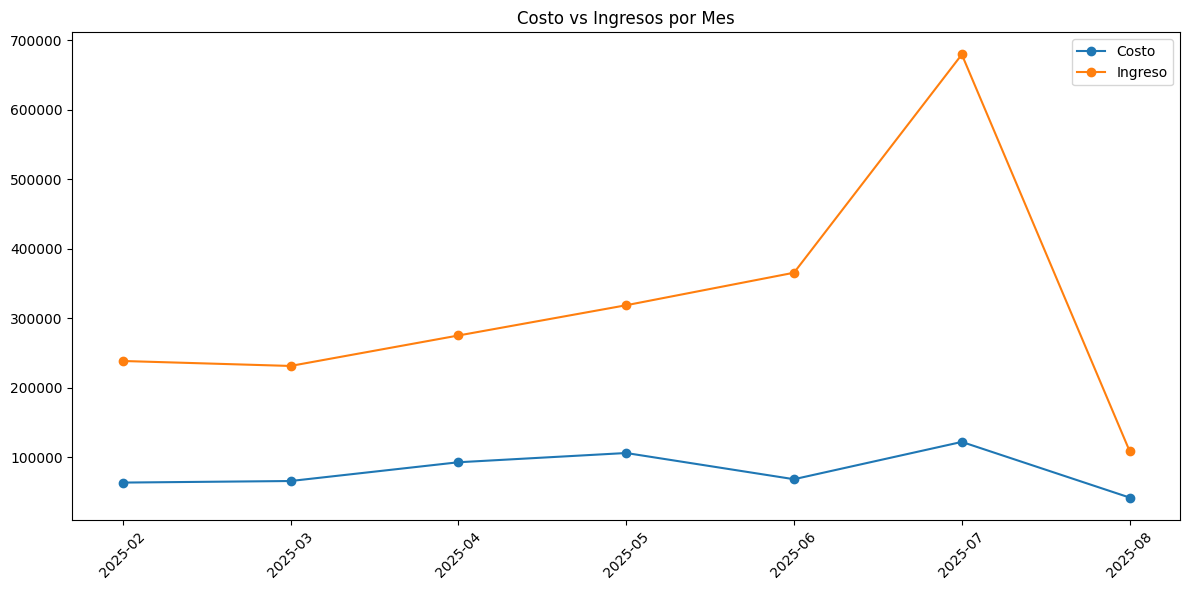

In [97]:

plt.figure(figsize=(12, 6))
plt.plot(mensual['mes'], mensual['costo_total_usd'], marker='o', label='Costo')
plt.plot(mensual['mes'], mensual['ingresos_usd'], marker='o', label='Ingreso')
plt.xticks(rotation=45)
plt.title('Costo vs Ingresos por Mes')
plt.legend()
plt.tight_layout()
plt.show()

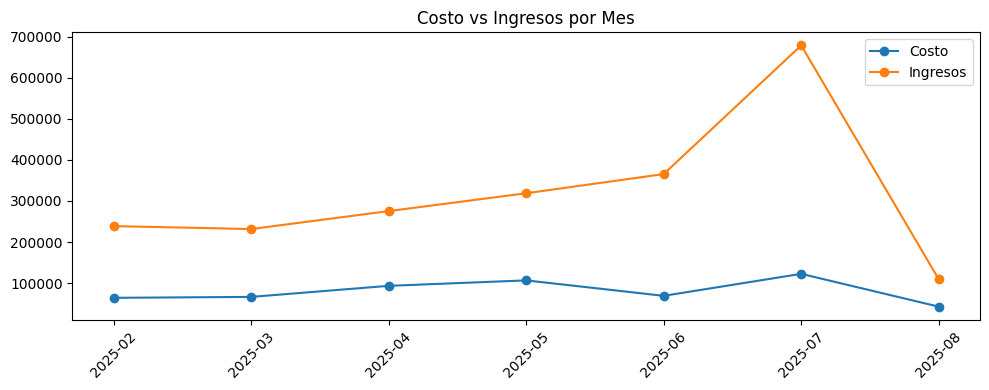

,mes,costo_total_usd,ingresos_usd
0,2025-02,63944.02,238731.31
1,2025-03,66190.11,231598.42
2,2025-04,93155.58,275373.67
3,2025-05,106454.46,318871.51
4,2025-06,68778.67,365618.97
5,2025-07,122397.09,679309.51
6,2025-08,42406.31,109139.31


In [56]:
mensual = df.copy()
mensual['mes'] = mensual['fecha'].dt.to_period('M').astype(str)
trend = mensual.groupby('mes', as_index=False)[['costo_total_usd', 'ingresos_usd']].sum()

if HAS_MATPLOTLIB:
    plt.figure(figsize=(10, 4))
    plt.plot(trend['mes'], trend['costo_total_usd'], marker='o', label='Costo')
    plt.plot(trend['mes'], trend['ingresos_usd'], marker='o', label='Ingresos')
    plt.xticks(rotation=45)
    plt.title('Costo vs Ingresos por Mes')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Grafica omitida: Costo vs Ingresos por Mes (matplotlib no disponible).')

trend


## 5. Analisis complementario

Este bloque agrega analisis faltantes de la consigna para conectar mejor el notebook con decisiones de negocio.


In [57]:
# Homologamos nombres de metricas con la consigna
df['ctr_link'] = df['prop_links']
df['cvr'] = df['prop_cvr']
df['cpa'] = df['costo_adquisicion']
df['cpc'] = df['costo_total_usd'] / df['link_clicks'].replace(0, 1)

df[['ctr_link', 'cvr', 'cpc', 'cpa', 'roas', 'roi']].describe().round(4)


,ctr_link,cvr,cpc,cpa,roas,roi
count,200.0000,200.0000,200.0000,200.0000,200.0000,200.0000
mean,0.0274,0.0967,5.4926,96.4797,3.0415,2.0415
std,0.0134,0.0545,10.9204,187.0212,3.6911,3.6911
min,0.0051,0.0000,0.2302,1.5814,0.0000,-1.0000
25%,0.0167,0.0526,1.0826,12.1638,0.4953,-0.5047
50%,0.0277,0.0962,2.4396,27.4521,1.5070,0.5070
75%,0.0376,0.1351,5.6772,81.4793,4.1344,3.1344
max,0.0582,0.2186,95.3273,1264.0400,18.1585,17.1585


In [58]:
# Mejor tipo de contenido por engagement, conversion y rentabilidad
analisis_contenido = (
    df.groupby('tipo_contenido', as_index=False)
      .agg(
          campanas=('id_campana', 'count'),
          engagement_promedio=('engagement_total', 'mean'),
          conversiones_promedio=('conversiones', 'mean'),
          roi_promedio=('roi', 'mean'),
          roas_promedio=('roas', 'mean'),
          cpa_promedio=('cpa', 'mean')
      )
      .sort_values('roi_promedio', ascending=False)
)

analisis_contenido.round(3)


,tipo_contenido,campanas,engagement_promedio,conversiones_promedio,roi_promedio,roas_promedio,cpa_promedio
1,Review,38,7171.684,562.974,3.425,4.425,83.133
2,Tutorial,40,7393.000,282.225,2.837,3.837,58.441
4,UGC_Paid,39,8128.385,195.538,1.559,2.559,160.441
0,Challenge,27,8131.519,137.667,1.258,2.258,88.901
3,UGC_Organic,56,5869.393,89.018,1.248,2.248,91.817


In [59]:
from IPython.display import display

def resumen_segmento(columna):
    return (
        df.groupby(columna, as_index=False)
          .agg(
              campanas=('id_campana', 'count'),
              roi_promedio=('roi', 'mean'),
              roi_mediano=('roi', 'median'),
              pct_roi_negativo=('roi', lambda s: (s < 0).mean() * 100),
              roas_promedio=('roas', 'mean'),
              ctr_promedio=('ctr_link', 'mean'),
              cvr_promedio=('cvr', 'mean'),
              cpa_promedio=('cpa', 'mean')
          )
          .sort_values('roi_promedio', ascending=False)
          .round(3)
    )

print('Resumen por tier')
display(resumen_segmento('tier'))

print('Resumen por plataforma')
display(resumen_segmento('plataforma'))

print('Resumen por pais')
display(resumen_segmento('pais'))


Resumen por tier


,tier,campanas,roi_promedio,roi_mediano,pct_roi_negativo,roas_promedio,ctr_promedio,cvr_promedio,cpa_promedio
0,macro,37,4.318,2.626,24.324,5.318,0.027,0.092,46.254
2,mid,40,2.365,1.307,30.000,3.365,0.026,0.095,56.667
1,micro,72,2.086,0.828,37.500,3.086,0.028,0.102,53.221
3,nano,51,0.073,-0.503,68.627,1.073,0.029,0.094,225.215


Resumen por plataforma


,plataforma,campanas,roi_promedio,roi_mediano,pct_roi_negativo,roas_promedio,ctr_promedio,cvr_promedio,cpa_promedio
1,TikTok,84,3.146,2.165,29.762,4.146,0.031,0.097,71.630
0,Instagram,87,1.287,-0.002,50.575,2.287,0.025,0.100,101.196
2,YouTube Shorts,29,1.106,0.078,48.276,2.106,0.026,0.087,154.309


Resumen por pais


,pais,campanas,roi_promedio,roi_mediano,pct_roi_negativo,roas_promedio,ctr_promedio,cvr_promedio,cpa_promedio
1,CL,43,2.790,1.954,30.233,3.790,0.028,0.096,47.186
3,MX,40,2.560,0.196,50.000,3.560,0.029,0.093,110.424
0,AR,36,1.777,0.879,36.111,2.777,0.026,0.108,137.019
2,CO,37,1.699,0.498,43.243,2.699,0.026,0.104,117.860
4,PE,44,1.343,0.052,47.727,2.343,0.029,0.085,80.829


In [60]:
# Riesgo: que segmentos concentran campanas con ROI negativo
riesgo_tier = (
    df.assign(roi_negativo=df['roi'] < 0)
      .groupby('tier', as_index=False)
      .agg(
          campanas=('id_campana', 'count'),
          campanas_roi_negativo=('roi_negativo', 'sum'),
          proporcion_roi_negativo=('roi_negativo', lambda s: s.mean() * 100),
          roi_q25=('roi', lambda s: s.quantile(0.25)),
          roi_mediana=('roi', 'median'),
          roi_q75=('roi', lambda s: s.quantile(0.75))
      )
      .sort_values('proporcion_roi_negativo', ascending=False)
      .round(3)
)

matriz_roi = df.pivot_table(
    index='plataforma',
    columns='tipo_contenido',
    values='roi',
    aggfunc='mean'
).round(3)

print('Riesgo por tier')
display(riesgo_tier)

print('Matriz ROI promedio: plataforma x tipo_contenido')
display(matriz_roi)


Riesgo por tier


,tier,campanas,campanas_roi_negativo,proporcion_roi_negativo,roi_q25,roi_mediana,roi_q75
3,nano,51,35,68.627,-0.836,-0.503,0.420
1,micro,72,27,37.500,-0.230,0.828,3.594
2,mid,40,12,30.000,-0.143,1.307,3.309
0,macro,37,9,24.324,0.116,2.626,7.659


Matriz ROI promedio: plataforma x tipo_contenido


tipo_contenido,Challenge,Review,Tutorial,UGC_Organic,UGC_Paid
plataforma,,,,,
Instagram,1.771,1.604,1.946,0.526,0.717
TikTok,0.934,5.192,4.748,1.947,2.497
YouTube Shorts,0.169,3.965,-0.458,0.440,1.949


In [61]:
# Campanas extremas para detectar oportunidades y riesgos
columnas_revision = [
    'id_campana', 'marca', 'tier', 'plataforma', 'tipo_contenido',
    'costo_total_usd', 'ingresos_usd', 'conversiones', 'roas', 'roi'
]

print('Top 5 campanas por ROI')
display(df.sort_values('roi', ascending=False)[columnas_revision].head(5).round(3))

print('Top 5 campanas con peor ROI')
display(df.sort_values('roi', ascending=True)[columnas_revision].head(5).round(3))


Top 5 campanas por ROI


,id_campana,marca,tier,plataforma,tipo_contenido,costo_total_usd,ingresos_usd,conversiones,roas,roi
146,UGC-0147,NovaSkin,macro,TikTok,Review,11514.08,209078.00,7281,18.158,17.158
32,UGC-0033,UrbanFit,macro,TikTok,Review,7050.29,115796.90,4450,16.424,15.424
169,UGC-0170,NovaSkin,macro,YouTube Shorts,Review,7313.41,119967.55,1429,16.404,15.404
121,UGC-0122,GlowTech,mid,TikTok,Review,1953.44,31650.89,353,16.203,15.203
140,UGC-0141,UrbanFit,micro,TikTok,Tutorial,985.26,15620.61,240,15.854,14.854


Top 5 campanas con peor ROI


,id_campana,marca,tier,plataforma,tipo_contenido,costo_total_usd,ingresos_usd,conversiones,roas,roi
178,UGC-0179,GlowTech,nano,TikTok,UGC_Organic,933.86,0.00,0,0.000,-1.000
167,UGC-0168,CasaZen,nano,Instagram,UGC_Paid,1264.04,0.00,0,0.000,-1.000
88,UGC-0089,NovaSkin,nano,Instagram,UGC_Paid,772.29,16.17,1,0.021,-0.979
37,UGC-0038,CasaZen,nano,TikTok,Challenge,1048.60,23.31,1,0.022,-0.978
91,UGC-0092,NovaSkin,macro,YouTube Shorts,Review,9612.68,327.09,23,0.034,-0.966


## 6. Graficas faltantes

Se agregan dos visualizaciones pedidas en la actividad para comparar segmentos y relacionar escala con resultados.


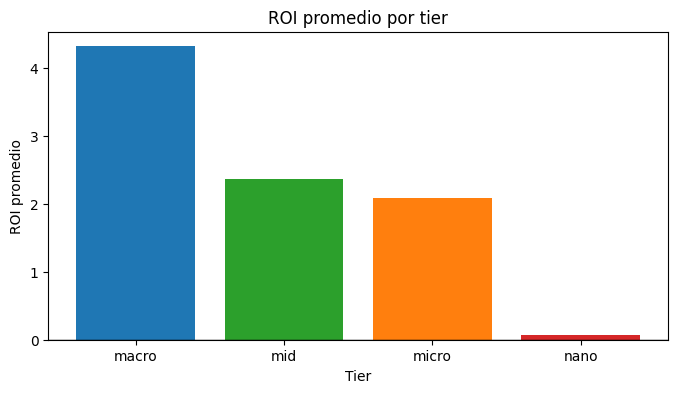

,tier,roi
0,macro,4.318205
2,mid,2.364625
1,micro,2.086349
3,nano,0.073042


In [62]:
roi_tier = df.groupby('tier', as_index=False)['roi'].mean().sort_values('roi', ascending=False)

if HAS_MATPLOTLIB:
    plt.figure(figsize=(8, 4))
    plt.bar(roi_tier['tier'], roi_tier['roi'], color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
    plt.axhline(0, color='black', linewidth=1)
    plt.title('ROI promedio por tier')
    plt.xlabel('Tier')
    plt.ylabel('ROI promedio')
    plt.show()
else:
    print('Grafica omitida: ROI promedio por tier (matplotlib no disponible).')

roi_tier


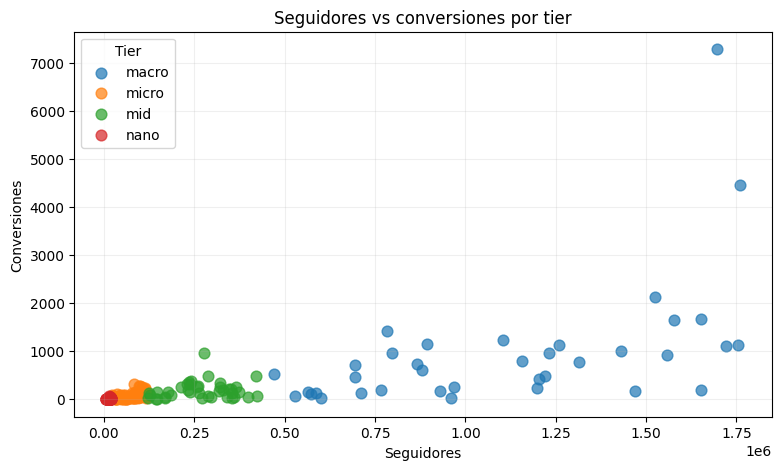

,tier,seguidores,conversiones
146,macro,1695431,7281
32,macro,1760371,4450
176,macro,1525044,2123
152,macro,1652765,1662
64,macro,1576420,1648
169,macro,782165,1429
137,macro,1105356,1233
157,macro,893898,1153
98,macro,1753984,1121
179,macro,1257879,1121


In [63]:
colores_tier = {
    'nano': '#d62728',
    'micro': '#ff7f0e',
    'mid': '#2ca02c',
    'macro': '#1f77b4'
}

if HAS_MATPLOTLIB:
    plt.figure(figsize=(9, 5))
    for tier, subset in df.groupby('tier'):
        plt.scatter(
            subset['seguidores'],
            subset['conversiones'],
            alpha=0.7,
            s=60,
            label=tier,
            color=colores_tier.get(tier, '#333333')
        )

    plt.title('Seguidores vs conversiones por tier')
    plt.xlabel('Seguidores')
    plt.ylabel('Conversiones')
    plt.legend(title='Tier')
    plt.grid(alpha=0.2)
    plt.show()
else:
    print('Grafica omitida: Seguidores vs conversiones por tier (matplotlib no disponible).')

df[['tier', 'seguidores', 'conversiones']].sort_values(['tier', 'conversiones'], ascending=[True, False]).head(10)
